# L07. CNN Basics

FashionMNIST를 사용해 `Conv2d`, `MaxPool2d`, feature map, 간단한 CNN 학습 흐름을 확인합니다.


## 1. 데이터 준비

CNN에서는 이미지를 펼치지 않고 `(batch, channel, height, width)` 형태로 사용합니다.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split, Subset
from torchvision import datasets, transforms

np.random.seed(42)
torch.manual_seed(42)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'

class_names = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]

transform = transforms.ToTensor()

full_train = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

small_train = Subset(full_train, range(2000))
train_dataset, val_dataset = random_split(
    small_train,
    [1600, 400],
    generator=torch.Generator().manual_seed(42),
)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(Subset(test_dataset, range(512)), batch_size=64, shuffle=False)

images, labels = next(iter(train_loader))
print('images shape:', tuple(images.shape))
print('labels shape:', tuple(labels.shape))


images shape: (64, 1, 28, 28)
labels shape: (64,)


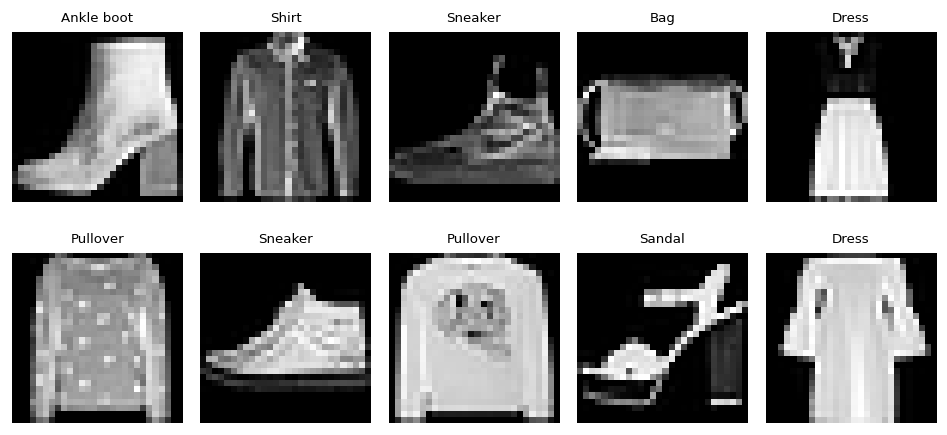

In [2]:
fig, axes = plt.subplots(2, 5, figsize=(8, 4))
axes = axes.ravel()

for i, ax in enumerate(axes):
    ax.imshow(images[i, 0], cmap='gray')
    ax.set_title(class_names[labels[i].item()], fontsize=8)
    ax.axis('off')

plt.tight_layout()
plt.show()


## 2. Convolution 계산 보기

작은 입력과 작은 커널로 convolution 계산을 직접 확인합니다.


In [3]:
input_image = np.array([
    [0, 0, 1, 1, 0],
    [0, 1, 1, 1, 0],
    [0, 1, 0, 0, 0],
    [1, 1, 0, 0, 0],
    [0, 0, 0, 0, 0],
], dtype=float)

kernel = np.array([
    [1, 0, -1],
    [1, 0, -1],
    [1, 0, -1],
], dtype=float)

feature_map = np.zeros((3, 3))
for i in range(3):
    for j in range(3):
        patch = input_image[i:i+3, j:j+3]
        feature_map[i, j] = np.sum(patch * kernel)

print('feature map =\n', feature_map)


feature map =
 [[-2.  0.  2.]
 [ 0.  2.  1.]
 [ 1.  2.  0.]]


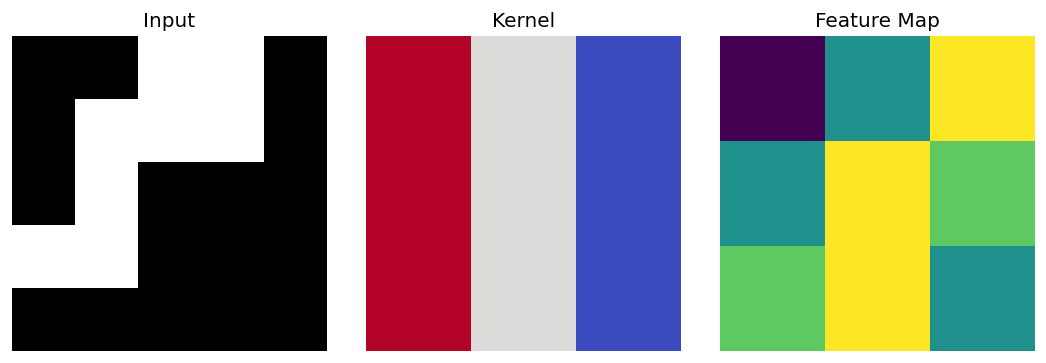

In [4]:
plt.figure(figsize=(9, 3))

plt.subplot(1, 3, 1)
plt.imshow(input_image, cmap='gray')
plt.title('Input')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(kernel, cmap='coolwarm')
plt.title('Kernel')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(feature_map, cmap='viridis')
plt.title('Feature Map')
plt.axis('off')

plt.tight_layout()
plt.show()


## 3. Conv2d와 MaxPool2d 확인

`nn.Conv2d`는 feature map을 만들고, `nn.MaxPool2d`는 feature map 크기를 줄입니다.


In [5]:
conv = nn.Conv2d(in_channels=1, out_channels=4, kernel_size=3, stride=1, padding=1)
pool = nn.MaxPool2d(kernel_size=2, stride=2)

x = images[:4]
conv_out = conv(x)
pool_out = pool(conv_out)

print('input shape :', tuple(x.shape))
print('conv out shape:', tuple(conv_out.shape))
print('pool out shape:', tuple(pool_out.shape))


input shape : (4, 1, 28, 28)
conv out shape: (4, 4, 28, 28)
pool out shape: (4, 4, 14, 14)


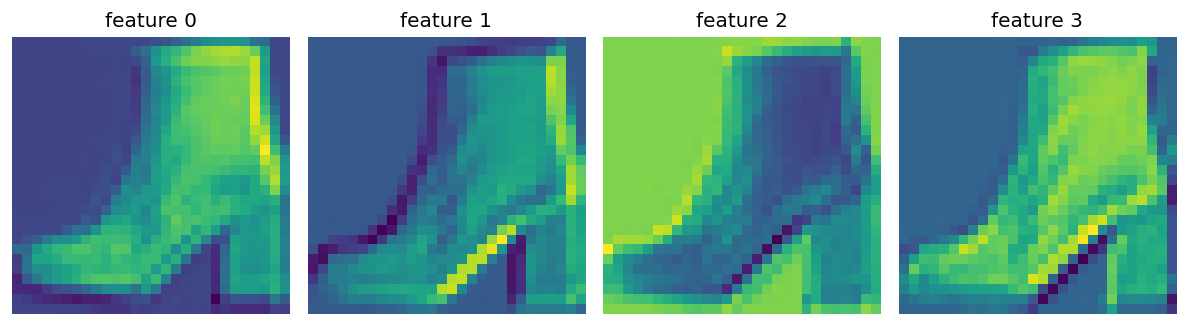

In [6]:
fig, axes = plt.subplots(1, 4, figsize=(10, 3))

for i in range(4):
    axes[i].imshow(conv_out[0, i].detach().numpy(), cmap='viridis')
    axes[i].set_title(f'feature {i}')
    axes[i].axis('off')

plt.tight_layout()
plt.show()


## 4. CNN 모델 만들기

구조: `Conv -> ReLU -> Pool -> Conv -> ReLU -> Pool -> Linear`


In [7]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 8, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(8, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(16 * 7 * 7, 64),
            nn.ReLU(),
            nn.Linear(64, 10),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model = SimpleCNN()
print(model)


SimpleCNN(
  (features): Sequential(
    (0): Conv2d(1, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=64, bias=True)
    (2): ReLU()
    (3): Linear(in_features=64, out_features=10, bias=True)
  )
)


In [8]:
def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_count = 0

    with torch.no_grad():
        for x, y in loader:
            logits = model(x)
            loss = criterion(logits, y)
            total_loss += loss.item() * x.size(0)
            total_correct += (logits.argmax(dim=1) == y).sum().item()
            total_count += x.size(0)

    return total_loss / total_count, total_correct / total_count


def train_model(model, train_loader, val_loader, optimizer, criterion, epochs=5):
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(epochs):
        model.train()
        total_loss = 0.0
        total_correct = 0
        total_count = 0

        for x, y in train_loader:
            optimizer.zero_grad()
            logits = model(x)
            loss = criterion(logits, y)
            loss.backward()
            optimizer.step()

            total_loss += loss.item() * x.size(0)
            total_correct += (logits.argmax(dim=1) == y).sum().item()
            total_count += x.size(0)

        train_loss = total_loss / total_count
        train_acc = total_correct / total_count
        val_loss, val_acc = evaluate(model, val_loader, criterion)

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        print(
            f"epoch {epoch + 1:02d}: "
            f"train_loss={train_loss:.4f}, train_acc={train_acc:.4f}, "
            f"val_loss={val_loss:.4f}, val_acc={val_acc:.4f}"
        )

    return history


In [9]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

history = train_model(model, train_loader, val_loader, optimizer, criterion, epochs=5)
print('final val loss:', round(history['val_loss'][-1], 4))
print('final val acc :', round(history['val_acc'][-1], 4))


epoch 01: train_loss=2.2609, train_acc=0.1806, val_loss=2.1422, val_acc=0.3825
epoch 02: train_loss=1.7620, train_acc=0.4719, val_loss=1.2774, val_acc=0.5950
epoch 03: train_loss=1.0202, train_acc=0.6312, val_loss=0.8718, val_acc=0.7050
epoch 04: train_loss=0.8082, train_acc=0.6881, val_loss=0.7727, val_acc=0.7225
epoch 05: train_loss=0.7329, train_acc=0.7219, val_loss=0.7424, val_acc=0.7250
final val loss: 0.7424
final val acc : 0.725


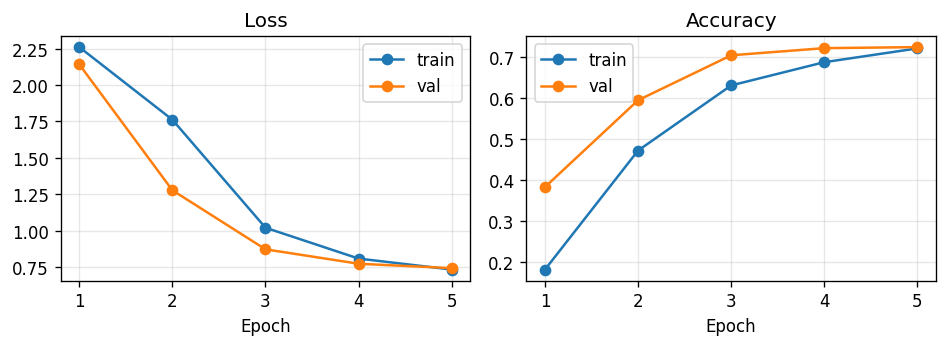

In [10]:
epochs = range(1, 6)

plt.figure(figsize=(8, 3))

plt.subplot(1, 2, 1)
plt.plot(epochs, history['train_loss'], marker='o', label='train')
plt.plot(epochs, history['val_loss'], marker='o', label='val')
plt.title('Loss')
plt.xlabel('Epoch')
plt.grid(alpha=0.3)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, history['train_acc'], marker='o', label='train')
plt.plot(epochs, history['val_acc'], marker='o', label='val')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()


In [11]:
test_loss, test_acc = evaluate(model, test_loader, criterion)
print(f'test loss = {test_loss:.4f}')
print(f'test acc = {test_acc:.4f}')


test loss = 0.7190
test acc = 0.6895


## 5. MLP와 CNN 비교

| 항목 | MLP | CNN |
|---|---|---|
| 입력 처리 | 이미지를 펼침 | 2차원 구조 유지 |
| 주요 층 | Linear | Conv2d |
| 공간 정보 활용 | 약함 | 강함 |
| 파라미터 공유 | 없음 | 있음 |
| 이미지 처리 적합성 | 낮음 | 높음 |

## 6. 핵심 정리

- convolution은 작은 커널을 이동시키며 특징을 추출합니다.
- feature map은 convolution의 출력입니다.
- pooling은 feature map 크기를 줄입니다.
- CNN은 이미지의 2차원 구조를 유지하면서 학습합니다.



## 8. 연습문제 풀이

아래 셀들은 앞에서 만든 `images`, `train_loader`, `val_loader`, `test_loader`, `SimpleCNN`, `evaluate`, `train_model`을 그대로 사용합니다.


### Exercise 1 풀이

`out_channels`는 convolution이 만들어내는 feature map의 개수입니다. 입력이 `(batch, 1, 28, 28)`이고 `padding=1`, `kernel_size=3`이면 공간 크기는 유지되고 채널 수만 `out_channels`와 같아집니다.


In [12]:
for out_channels in [4, 8, 16]:
    conv_test = nn.Conv2d(in_channels=1, out_channels=out_channels, kernel_size=3, padding=1)
    y = conv_test(images[:4])
    print(f'out_channels={out_channels:2d} -> output shape={tuple(y.shape)}')


out_channels= 4 -> output shape=(4, 4, 28, 28)
out_channels= 8 -> output shape=(4, 8, 28, 28)
out_channels=16 -> output shape=(4, 16, 28, 28)


### Exercise 2 풀이

첫 번째 convolution의 `kernel_size`를 5로 키우면 한 번에 보는 영역이 넓어집니다. `padding=2`를 함께 쓰면 출력 feature map의 높이와 너비는 28 x 28로 유지됩니다. 파라미터 수는 `3x3`보다 `5x5`가 더 많습니다.


In [13]:
conv3 = nn.Conv2d(1, 8, kernel_size=3, padding=1)
conv5 = nn.Conv2d(1, 8, kernel_size=5, padding=2)

print('3x3 output shape:', tuple(conv3(images[:4]).shape))
print('5x5 output shape:', tuple(conv5(images[:4]).shape))
print('3x3 parameters:', sum(p.numel() for p in conv3.parameters()))
print('5x5 parameters:', sum(p.numel() for p in conv5.parameters()))

class Kernel5CNN(SimpleCNN):
    def __init__(self):
        super().__init__()
        self.features[0] = nn.Conv2d(1, 8, kernel_size=5, padding=2)

kernel5_model = Kernel5CNN()
kernel5_optimizer = torch.optim.Adam(kernel5_model.parameters(), lr=1e-3)
kernel5_criterion = nn.CrossEntropyLoss()
kernel5_history = train_model(kernel5_model, train_loader, val_loader, kernel5_optimizer, kernel5_criterion, epochs=3)

print('kernel_size=5 final val acc:', round(kernel5_history['val_acc'][-1], 4))


3x3 output shape: (4, 8, 28, 28)
5x5 output shape: (4, 8, 28, 28)
3x3 parameters: 80
5x5 parameters: 208
epoch 01: train_loss=2.1353, train_acc=0.3006, val_loss=1.7545, val_acc=0.4400
epoch 02: train_loss=1.2808, train_acc=0.5519, val_loss=1.0149, val_acc=0.6325
epoch 03: train_loss=0.9194, train_acc=0.6500, val_loss=0.8518, val_acc=0.6925
kernel_size=5 final val acc: 0.6925


### Exercise 3 풀이

`MaxPool2d`를 제거하면 feature map의 공간 크기가 줄지 않습니다. 따라서 classifier로 들어가는 벡터가 훨씬 커지고, 파라미터 수와 계산량이 증가합니다.


In [14]:
class NoPoolCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 8, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(8, 16, kernel_size=3, padding=1),
            nn.ReLU(),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(16 * 28 * 28, 64),
            nn.ReLU(),
            nn.Linear(64, 10),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

no_pool_model = NoPoolCNN()
with torch.no_grad():
    no_pool_features = no_pool_model.features(images[:4])

print('without pooling feature shape:', tuple(no_pool_features.shape))
print('without pooling parameters:', sum(p.numel() for p in no_pool_model.parameters()))
print('baseline CNN parameters:', sum(p.numel() for p in SimpleCNN().parameters()))

no_pool_optimizer = torch.optim.Adam(no_pool_model.parameters(), lr=1e-3)
no_pool_history = train_model(no_pool_model, train_loader, val_loader, no_pool_optimizer, nn.CrossEntropyLoss(), epochs=3)
print('no-pool final val acc:', round(no_pool_history['val_acc'][-1], 4))


without pooling feature shape: (4, 16, 28, 28)
without pooling parameters: 804778
baseline CNN parameters: 52138
epoch 01: train_loss=1.5533, train_acc=0.4525, val_loss=0.8818, val_acc=0.7075
epoch 02: train_loss=0.7549, train_acc=0.7381, val_loss=0.6824, val_acc=0.7475
epoch 03: train_loss=0.5965, train_acc=0.7937, val_loss=0.6178, val_acc=0.7850
no-pool final val acc: 0.785


### Exercise 4 풀이

classifier의 hidden dimension을 64에서 128로 늘리면 표현력과 파라미터 수가 증가합니다. 작은 데이터에서는 validation accuracy가 좋아질 수도 있지만, 항상 좋아지는 것은 아니며 overfitting 가능성도 커집니다.


In [15]:
class Hidden128CNN(SimpleCNN):
    def __init__(self):
        super().__init__()
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(16 * 7 * 7, 128),
            nn.ReLU(),
            nn.Linear(128, 10),
        )

hidden128_model = Hidden128CNN()
print('hidden=64 parameters :', sum(p.numel() for p in SimpleCNN().parameters()))
print('hidden=128 parameters:', sum(p.numel() for p in hidden128_model.parameters()))

hidden128_optimizer = torch.optim.Adam(hidden128_model.parameters(), lr=1e-3)
hidden128_history = train_model(hidden128_model, train_loader, val_loader, hidden128_optimizer, nn.CrossEntropyLoss(), epochs=3)
print('hidden=128 final val acc:', round(hidden128_history['val_acc'][-1], 4))


hidden=64 parameters : 52138
hidden=128 parameters: 103018
epoch 01: train_loss=1.9919, train_acc=0.3106, val_loss=1.4385, val_acc=0.4825
epoch 02: train_loss=1.0929, train_acc=0.5919, val_loss=0.9173, val_acc=0.6450
epoch 03: train_loss=0.8776, train_acc=0.6569, val_loss=0.8100, val_acc=0.7075
hidden=128 final val acc: 0.7075


### Exercise 5 풀이

MLP는 이미지를 1차원으로 펼쳐서 학습하므로 2차원 공간 구조를 직접 활용하지 못합니다. CNN은 convolution으로 지역 패턴을 공유 파라미터로 학습하므로 이미지 분류에 더 자연스럽게 맞습니다.


In [16]:
class SimpleMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 10),
        )

    def forward(self, x):
        return self.net(x)

mlp_model = SimpleMLP()
mlp_optimizer = torch.optim.Adam(mlp_model.parameters(), lr=1e-3)
mlp_history = train_model(mlp_model, train_loader, val_loader, mlp_optimizer, nn.CrossEntropyLoss(), epochs=3)

print('MLP final val acc:', round(mlp_history['val_acc'][-1], 4))
print('CNN final val acc:', round(history['val_acc'][-1], 4))

comparison = {
    'baseline_cnn': history['val_acc'][-1],
    'kernel5_cnn': kernel5_history['val_acc'][-1],
    'no_pool_cnn': no_pool_history['val_acc'][-1],
    'hidden128_cnn': hidden128_history['val_acc'][-1],
    'mlp': mlp_history['val_acc'][-1],
}

for name, acc in sorted(comparison.items(), key=lambda item: item[1], reverse=True):
    print(f'{name:14s}: {acc:.4f}')


epoch 01: train_loss=1.7584, train_acc=0.4781, val_loss=1.1731, val_acc=0.6350
epoch 02: train_loss=0.9578, train_acc=0.6663, val_loss=0.8395, val_acc=0.7025
epoch 03: train_loss=0.7631, train_acc=0.7219, val_loss=0.8192, val_acc=0.7175
MLP final val acc: 0.7175
CNN final val acc: 0.725
no_pool_cnn   : 0.7850
baseline_cnn  : 0.7250
mlp           : 0.7175
hidden128_cnn : 0.7075
kernel5_cnn   : 0.6925
